In [ ]:
import requests
from bs4 import BeautifulSoup

search_query = "iPhone"
search_url = f"https://en.wikinews.org/w/index.php?search={search_query}&title=Special%3ASearch&profile=default&fulltext=1"

response = requests.get(search_url, headers={"User-Agent": "Mozilla/5.0"})

if response.status_code == 200:
    soup = BeautifulSoup(response.text, "html.parser")
    news = soup.select("div.mw-search-result-heading a")

    if news:
        print(f"Wikinews Search Results for '{search_query}':")
        for item in news:
            title = item.text
            link = "https://en.wikinews.org" + item["href"]
            print(f"- {title}: {link}")
    else:
        print(f"No news articles found for '{search_query}'.")
else:
    print("Failed to fetch the page")

Wikinews Search Results for 'iPhone':
- Nokia Inc. announces plans for iPhone rival: https://en.wikinews.org/wiki/Nokia_Inc._announces_plans_for_iPhone_rival
- Apple unveils iPhone 4, iOS 4 at Worldwide Developers Conference 2010: https://en.wikinews.org/wiki/Apple_unveils_iPhone_4,_iOS_4_at_Worldwide_Developers_Conference_2010
- Apple launches new, faster iPhone: https://en.wikinews.org/wiki/Apple_launches_new,_faster_iPhone
- Apple concerned with iPhone icons' alleged misuse: https://en.wikinews.org/wiki/Apple_concerned_with_iPhone_icons%27_alleged_misuse
- Cisco sues Apple for iPhone trademark: https://en.wikinews.org/wiki/Cisco_sues_Apple_for_iPhone_trademark
- Fans worldwide queue for new iPhone: https://en.wikinews.org/wiki/Fans_worldwide_queue_for_new_iPhone
- Release of 'Verizon iPhone' set for early February: https://en.wikinews.org/wiki/Release_of_%27Verizon_iPhone%27_set_for_early_February
- Apple swamped by iPhone 4 pre-orders: https://en.wikinews.org/wiki/Apple_swamped_by_

In [ ]:
#API
import requests

query = "iphone"
url = "https://en.wikipedia.org/w/api.php?action=query&format=json&list=search&srsearch=" + query + "&srlimit=50"

response = requests.get(url)
data = response.json()

results = data["query"]["search"]

print("Wikipedia results:")
for item in results:
    print(item["title"] + " - " + item["snippet"])

Wikipedia results:
IPhone - The <span class="searchmatch">iPhone</span> is a line of smartphones developed and marketed by Apple that run iOS, which is the company&#039;s own mobile operating system. The first-generation
IOS - iOS (formerly <span class="searchmatch">iPhone</span> OS) is a mobile operating system developed by Apple exclusively for its mobile devices. It was unveiled in January 2007 for the first-generation
App Store (Apple) - <span class="searchmatch">iPhone</span>, iPod Touch, or iPad, and some can be transferred to the Apple Watch smartwatch or 4th-generation or newer Apple TVs as extensions of <span class="searchmatch">iPhone</span> apps
IPhone 13 - The <span class="searchmatch">iPhone</span> 13 and <span class="searchmatch">iPhone</span> 13 Mini (stylized as <span class="searchmatch">iPhone</span> 13 mini) are smartphones developed and marketed by Apple. They are the fifteenth generation of iPhones
List of iPhone models - connectivity. As of 2025, the most recent <s

In [ ]:
#selenium
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import time

chrome_options = Options()
chrome_options.add_argument("no-sandbox")
chrome_options.add_argument("disable-gpu")

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

query = "iphones"
url = f"https://en.wikipedia.org/w/index.php?search={query}"
driver.get(url)

time.sleep(10)

soup = BeautifulSoup(driver.page_source, "html.parser")
items = soup.find_all("div", class_="mw-search-result")

print(" All Wikipedia Search Results")
for item in items:
    title = item.find("a")
    description = item.find("div", class_="searchresult")
    if title:
        desc_text = description.text.strip() if description else "No description"
        print(f" {title.text} - {desc_text}")

driver.quit()

ModuleNotFoundError: No module named 'selenium'

<Response [200]>
Wikinews Headlines about iPhone:
<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-disabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-disabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-not-available" dir="ltr" lang="en">
 <head>
  <meta charset="utf-8"/>
  <title>
   Wikinews, the free news source
  </title>
  <script>
   (function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limi

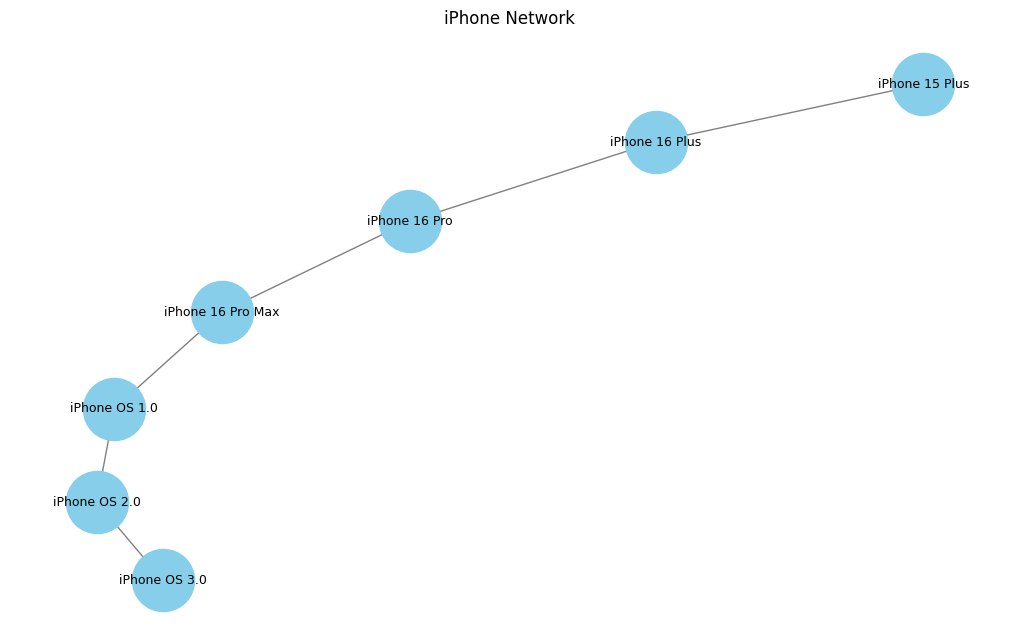

In [ ]:
# network x and cleaning for web scraping
"""Info Harvesters

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/18l5RiXwIoNP48gm23NkhI9lxaTrzbUzr
"""

import networkx as nx
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup

url = "https://en.wikinews.org/wiki/Main_Page"
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
print(response)

soup = BeautifulSoup(response.text, "html.parser")
news = soup.select("div.mw-parser-output ul li a")
print("Wikinews Headlines about iPhone:")
print(soup.prettify())

def iphone(model):
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query", "format": "json", "titles": model,
        "prop": "extracts|pageimages|info", "exintro": True, "explaintext": True,
        "pithumbsize": 500, "inprop": "url"
    }

    res = requests.get(url, params=params).json()
    page = list(res.get("query", {}).get("pages", {}).values())[0]

    return {
        "name": model,
        "desc": page.get("extract", "No description.")[:100] + "...",
        "img": page.get("thumbnail", {}).get("source", "No image."),
        "url": page.get("fullurl", "No link.")
    }

models = ["iPhone 12", "iPhone 13", "iPhone 14", "iPhone 15"]
for data in map(iphone, models):
    print(f" {data['name']}\n {data['desc']}\n {data['img']}\n {data['url']}\n")

def iphone(model):
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query", "format": "json", "titles": model,
        "prop": "extracts|pageimages|info", "exintro": True, "explaintext": True,
        "pithumbsize": 500, "inprop": "url"
    }

    res = requests.get(url, params=params).json()
    page = list(res.get("query", {}).get("pages", {}).values())[0]

    return {
        "name": model,
        "desc": page.get("extract", "No description.")[:100] + "...",
        "img": page.get("thumbnail", {}).get("source", "No image."),
        "url": page.get("fullurl", "No link."),
        "status": "Cleaning "
    }

models = ["iPhone 12", "iPhone 13", "iPhone 14", "iPhone 15"]
for data in map(iphone, models):
    print(f" {data['name']}\n {data['desc']}\n {data['img']}\n {data['url']}\n🧹 {data['status']}\n")

def iphone(model):
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query", "format": "json", "titles": model,
        "prop": "extracts|pageimages|info", "exintro": True, "explaintext": True,
        "pithumbsize": 500, "inprop": "url"
    }

    res = requests.get(url, params=params).json()
    page = list(res.get("query", {}).get("pages", {}).values())[0]

    return {
        "name": model,
        "desc": page.get("extract", "No description.")[:100] + "...",
        "img": page.get("thumbnail", {}).get("source", "No image."),
        "url": page.get("fullurl", "No link.")
    }
models = ["iPhone 12", "iPhone 13", "iPhone 14", "iPhone 15"]
for data in map(iphone, models):
    print(f" {data['name']}\n {data['desc']}\n Image: {data['img']}\n {data['url']}\n")

def iphone(model):
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query", "format": "json", "titles": model,
        "prop": "extracts|pageimages|info", "exintro": True, "explaintext": True,
        "pithumbsize": 500, "inprop": "url"
    }

    res = requests.get(url, params=params).json()
    page = list(res.get("query", {}).get("pages", {}).values())[0]

    return {
        "name": model,
        "desc": page.get("extract", "No description.")[:100] + "...",
        "img": page.get("thumbnail", {}).get("source", "No image.") ,
        "url": page.get("fullurl", "No link."),
        "status": "Cleaning "
    }
models = ["iPhone 12", "iPhone 13", "iPhone 14", "iPhone 15"]
for data in map(iphone, models):
    print(f" {data['name']}\n {data['desc']}\n Image: {data['img']}\n {data['url']}\n🧹 {data['status']}\n")

def get_iphone_models():
    url = "https://en.wikipedia.org/wiki/IPhone"
    res = requests.get(url)
    soup = BeautifulSoup(res.text, "html.parser")

    iphones = [
        row.find("td").text.strip()
        for table in soup.find_all("table", class_="wikitable")
        for row in table.find_all("tr")[1:]
        if row.find("td") and "iPhone" in row.find("td").text
    ]
    return iphones

def build_network(iphones):
    G = nx.Graph()
    G.add_nodes_from(iphones)
    G.add_edges_from((iphones[i], iphones[i + 1]) for i in range(len(iphones) - 1))
    return G

def plot_network(G):
    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color="skyblue", edge_color="gray", node_size=2000, font_size=9)
    plt.title("iPhone Network")
    plt.show()

iphones = get_iphone_models()
if iphones:
    plot_network(build_network(iphones))
else:
    print(" No iPhone data found.")

https://upload.wikimedia.org/wikipedia/en/4/4a/Commons-logo.svg
https://upload.wikimedia.org/wikipedia/commons/6/6d/First_iPhone_Macworld_2007_DSCF1286.agr.jpg
https://upload.wikimedia.org/wikipedia/commons/6/63/IOS_wordmark_%282017%29.svg
https://upload.wikimedia.org/wikipedia/commons/a/a2/IPhone_13_Pro_camera_lens_group.jpg
https://upload.wikimedia.org/wikipedia/commons/d/d2/IPhone_16_Pro_Vector.svg
https://upload.wikimedia.org/wikipedia/commons/a/a1/IPhone_3G_Availability.svg
https://upload.wikimedia.org/wikipedia/commons/7/7f/IPhone_6s_-_opened-92987.jpg
https://upload.wikimedia.org/wikipedia/en/8/8a/OOjs_UI_icon_edit-ltr-progressive.svg
https://upload.wikimedia.org/wikipedia/en/1/1b/Semi-protection-shackle.svg
https://upload.wikimedia.org/wikipedia/commons/4/49/Size_comparison_of_iPhone_5C_5S_4S.jpg
 News about iPhone:
- IPhone: accessibility features. Up to the <span class="searchmatch">iPhone</span> 8 and 8 Plus, <span class="searchmatch">i</span><span class="searchmatch">Phones

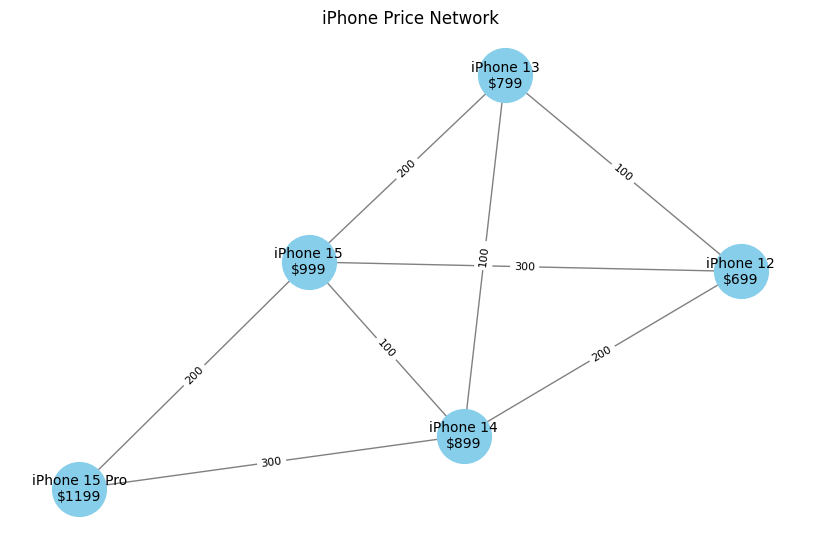

 IPhone
 accessibility features. Up to the <span class="searchmatch">iPhone</span> 8 and 8 Plus, <span class="searchmatch">i</span><span class="searchmatch">Phones</span> had a single button on the front panel, with the <span class="searchmatch">iPhone</span> 5s and later integrating a Touch
 https://en.wikipedia.org/?curid=8841749

 History of the iPhone
 of Mexico upheld that <span class="searchmatch">i</span>Fone is the rightful owner and held that Apple <span class="searchmatch">iPhone</span> is a trademark violation. In Brazil, the brand <span class="searchmatch">IPHONE</span> was registered in 2000
 https://en.wikipedia.org/?curid=13678080

 List of iPhone models
 The <span class="searchmatch">iPhone</span>, developed by Apple Inc., is a line of smartphones that combine a mobile <span class="searchmatch">phone</span>, digital camera, personal computer, and music player into one
 https://en.wikipedia.org/?curid=23241092

 IOS
 <span class="searchmatch">i</span>OS (formerly <span c

In [ ]:
# network x and cleaning for API
"""Info Harvester 1.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1_DsEEprLgtSpNPxav6MIY1Qxo471z_H7
"""

import requests

def get_images(topic="iPhone"):
    url = "https://en.wikipedia.org/w/api.php"

    def query(params):
        return requests.get(url, params=params).json().get("query", {}).get("pages", {})

    images = [img["title"] for p in query({"action": "query", "format": "json", "titles": topic, "prop": "images"}).values() for img in p.get("images", [])]

    return [p["imageinfo"][0]["url"] for name in images for p in query({"action": "query", "format": "json", "titles": name, "prop": "imageinfo", "iiprop": "url"}).values() if "imageinfo" in p]
for link in get_images():
    print(link)

import requests

def fetch_news(topic="iPhone"):
    url = f"https://en.wikipedia.org/w/api.php?action=query&format=json&list=search&srsearch={topic}&srlimit=10"
    data = requests.get(url).json()

    results = data.get("query", {}).get("search", [])

    print(f" News about {topic}:")
    for item in results:
        title = item["title"]
        snippet = item["snippet"]
        link = f"https://en.wikipedia.org/?curid={item['pageid']}"

        print(f"- {title}: {snippet}")
        print(f"  Read more: {link}\n")
fetch_news()

import requests

def get_iphone_info(models):
    url = "https://en.wikipedia.org/w/api.php"
    iphones = {}

    for model in models:
        res = requests.get(url, params={
            "action": "query",
            "format": "json",
            "titles": model,
            "prop": "extracts",
            "exintro": True,
            "explaintext": True,
            "pithumbsize": 500
        }).json()

        pages = res.get("query", {}).get("pages", {})
        for page in pages.values():
            iphones[model] = {
                "desc": page.get("extract", "No info."),
                "img": page.get("thumbnail", {}).get("source", "No image.")
            }

    return iphones

models = ["iPhone 12", "iPhone 13", "iPhone 14", "iPhone 15"]
iphones = get_iphone_info(models)

for name, data in iphones.items():
    print(f" {name}  {data['desc'][:100]}...\n {data['img']}\n")

import networkx as nx
import matplotlib.pyplot as plt

iphones = {
    "iPhone 12": 699,
    "iPhone 13": 799,
    "iPhone 14": 899,
    "iPhone 15": 999,
    "iPhone 15 Pro": 1199
}

def make_network():
    G = nx.Graph()

    for model, price in iphones.items():
        G.add_node(model, price=price)


    models = list(iphones.keys())
    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            diff = abs(iphones[models[i]] - iphones[models[j]])
            if diff <= 300:
                G.add_edge(models[i], models[j], weight=diff)

    return G

def draw_network(G):
    pos = nx.spring_layout(G, seed=42)
    labels = {node: f"{node}\n${G.nodes[node]['price']}" for node in G.nodes}

    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, labels=labels, node_color="skyblue", edge_color="gray", node_size=1500, font_size=10)

    edge_labels = {(u, v): f"{d['weight']}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("iPhone Price Network")
    plt.show()

G = make_network()
draw_network(G)

import requests

def fetch_news_cleaned():
    url = "https://en.wikipedia.org/w/api.php"
    params = {"action": "query", "format": "json", "list": "search", "srsearch": "iPhone", "srlimit": 10}

    response = requests.get(url, params=params)
    data = response.json().get("query", {}).get("search", [])

    news = [{"title": item["title"], "description": item["snippet"], "link": f"https://en.wikipedia.org/?curid={item['pageid']}"} for item in data]

    for item in news:
        print(f" {item['title']}\n {item['description']}\n {item['link']}\n")


fetch_news_cleaned()

import requests

def fetch_images(topic="iPhone"):
    url = "https://en.wikipedia.org/w/api.php"

    def get_pages(params):
        return requests.get(url, params=params).json().get("query", {}).get("pages", {})

    pages = get_pages({"action": "query", "format": "json", "titles": topic, "prop": "images"})
    images = [img["title"] for page in pages.values() for img in page.get("images", [])]

    return [
        page["imageinfo"][0]["url"]
        for img in images
        for page in get_pages({"action": "query", "format": "json", "titles": img, "prop": "imageinfo", "iiprop": "url"}).values()
        if "imageinfo" in page
    ]
print(fetch_images(), sep="\n")

import requests

def fetch_iphone_info(models):
    url = "https://en.wikipedia.org/w/api.php"

    def fetch(model):
        res = requests.get(url, params={
            "action": "query", "format": "json", "titles": model,
            "prop": "extracts|pageimages", "exintro": True, "explaintext": True, "pithumbsize": 500
        }).json()
        page = next(iter(res.get("query", {}).get("pages", {}).values()), {})
        return page.get("extract", "No info."), page.get("thumbnail", {}).get("source", "No image.")

    return {m: fetch(m) for m in models}
for name, (desc, img) in fetch_iphone_info(["iPhone 12", "iPhone 13", "iPhone 14", "iPhone 15"]).items():
    print(f" {name}\n {desc[:100]}...\n {img}\n")

In [ ]:
# network x and cleaning for selenium
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import time
import networkx as nx
import matplotlib.pyplot as plt


chrome_options = Options()
chrome_options.add_argument("--headless")
chrome_options.add_argument("--no-sandbox")
chrome_options.add_argument("--disable-gpu")

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)


query = "iPhones"
search_url = f"https://en.wikipedia.org/w/index.php?search={query}"
driver.get(search_url)
time.sleep(5)

soup = BeautifulSoup(driver.page_source, "html.parser")
items = soup.find_all("div", class_="mw-search-result")

iphones = []
for item in items[:10]:
    title_tag = item.find("a")
    desc_tag = item.find("div", class_="searchresult")

    if title_tag:
        name = title_tag.text.strip()
        link = "https://en.wikipedia.org" + title_tag["href"]
        desc = desc_tag.text.strip() if desc_tag else "No description available."
        iphones.append({"name": name, "link": link, "desc": desc})


for iphone in iphones:
    driver.get(iphone["link"])
    time.sleep(3)
    page_soup = BeautifulSoup(driver.page_source, "html.parser")

    price_text = "Price not listed"
    for row in page_soup.find_all("tr"):
        if "Price" in row.text:
            price_text = row.find("td").text.strip() if row.find("td") else "Unknown"
            break
    iphone["price"] = price_text


driver.get("https://en.wikipedia.org/wiki/IPhone")
time.sleep(5)
soup = BeautifulSoup(driver.page_source, "html.parser")
images = []
for img in soup.find_all("img"):
    img_url = img.get("src", "")
    if "iphone" in img_url.lower():
        images.append(f"https:{img_url}")

driver.quit()


print("Collected iPhones:", iphones)
if not iphones:
    print("No iPhones found. Adding sample data for testing.")
    iphones = [
        {"name": "iPhone 12", "price": "$699", "desc": "Sample desc", "link": "#"},
        {"name": "iPhone 13", "price": "$799", "desc": "Sample desc", "link": "#"}
    ]


def network(iphones):
    G = nx.Graph()
    for iphone in iphones:
        G.add_node(iphone["name"], price=iphone["price"])
    for i in range(len(iphones) - 1):
        G.add_edge(iphones[i]["name"], iphones[i + 1]["name"])
    return G


def draw(G):
    if len(G.nodes) == 0:
        print("No data available to create the network graph.")
        return

    plt.figure(figsize=(12, 7))
    pos = nx.spring_layout(G, seed=42)
    labels = {node: f"{node}\n{G.nodes[node]['price']}" for node in G.nodes}
    nx.draw(G, pos, with_labels=True, labels=labels, node_color="skyblue", edge_color="gray", node_size=2500, font_size=9)
    plt.title("iPhone Network from Wikipedia")
    plt.show()


G = network(iphones)
draw(G)


for iphone in iphones:
    print(f"{iphone['name']}\n{iphone['price']}\n{iphone['desc']}\n{iphone['link']}\n")

print("\nAll iPhone Images:")
for img in images:
    print(img)

ModuleNotFoundError: No module named 'selenium'